# 5장 2강: 부스팅 계열 모델의 원리와 발전

## 실습 목표

이번 실습에서는 **Ames Housing** 데이터를 이용하여 부스팅 계열 모델의 순차 학습 원리와 주요 모델의 차이를 확인합니다.

- AdaBoost와 Gradient Boosting의 순차 학습 원리를 이해합니다.
- Gradient Boosting이 이전 모델의 잔차를 보완하는 흐름을 확인합니다.
- XGBoost와 LightGBM을 같은 데이터에서 비교합니다.
- `learning_rate`, `n_estimators`, `max_depth`의 역할을 확인합니다.
- Early Stopping의 목적을 이해합니다.
- 부스팅이 단계적으로 편향을 줄여가는 이유를 설명합니다.

> 이 실습에서는 5장 2강 교안에서 다룬 내용만 사용합니다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- scikit-learn
- xgboost
- lightgbm
- 데이터: `data/Ames_Housing.csv`

### 분석 목표

주택의 특성을 이용하여 `SalePrice`를 예측하는 회귀 문제입니다.

### 사용할 특성

- `OverallQual`
- `GrLivArea`
- `GarageCars`
- `GarageArea`
- `TotalBsmtSF`
- `1stFlrSF`
- `2ndFlrSF`
- `FullBath`
- `TotRmsAbvGrd`
- `YearBuilt`
- `YearRemodAdd`
- `Fireplaces`

예측 대상은 `SalePrice`입니다.

## 실습 준비

1. Ames Housing 데이터를 불러옵니다.
2. 사용할 숫자형 특성과 `SalePrice`를 선택합니다.
3. Train / Test 데이터로 분리합니다.
4. 같은 데이터에서 Gradient Boosting, XGBoost, LightGBM을 비교합니다.

In [6]:
import time

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

house = pd.read_csv("data/Ames_Housing.csv")

features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "FullBath",
    "TotRmsAbvGrd",
    "YearBuilt",
    "YearRemodAdd",
    "Fireplaces"
]

X = house[features]
y = house["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train 크기:", X_train.shape)
print("Test 크기:", X_test.shape)

print("\n[결측치]")
display(X.isna().sum().to_frame("missing"))

Train 크기: (1168, 12)
Test 크기: (292, 12)

[결측치]


,missing
OverallQual,0
GrLivArea,0
GarageCars,0
GarageArea,0
TotalBsmtSF,0
1stFlrSF,0
2ndFlrSF,0
FullBath,0
TotRmsAbvGrd,0
YearBuilt,0


---

# 필수 1. 부스팅의 순차 학습 원리 확인

## 문제 1. AdaBoost와 Gradient Boosting의 차이를 정리하세요.

### 요구사항

다음 두 모델이 이전 모델의 실수를 어떻게 보완하는지 각각 작성합니다.

- AdaBoost
- Gradient Boosting

### 확인 포인트

- AdaBoost는 틀린 샘플에 더 큰 가중치를 주는가?
- Gradient Boosting은 이전 모델의 잔차를 다음 모델이 학습하는가?

### Q1. AdaBoost와 Gradient Boosting은 각각 무엇에 집중하여 다음 모델을 학습하나요?

**답변:**  
AdaBoost는 이전 모델이 틀린 샘플의 가중치를 높여 집중하고, Gradient Boosting은 이전까지의 잔차(오차)를 다음 약한 학습기가 학습합니다.


## 문제 2. Gradient Boosting의 단계별 성능 변화를 확인하세요.

### 요구사항

1. `GradientBoostingRegressor`를 사용합니다.
2. `n_estimators=100`
3. `learning_rate=0.05`
4. `max_depth=2`
5. `random_state=42`
6. 모델을 학습합니다.
7. `staged_predict()`를 사용해 나무가 추가될 때마다 Test RMSE를 계산합니다.
8. 나무 개수에 따른 Test RMSE를 선 그래프로 나타냅니다.

### 확인 포인트

- 순차적으로 나무가 추가되면서 예측 오차가 감소하는 구간을 확인했는가?
- 이전까지 설명하지 못한 부분을 다음 나무가 보완한다는 개념과 연결할 수 있는가?

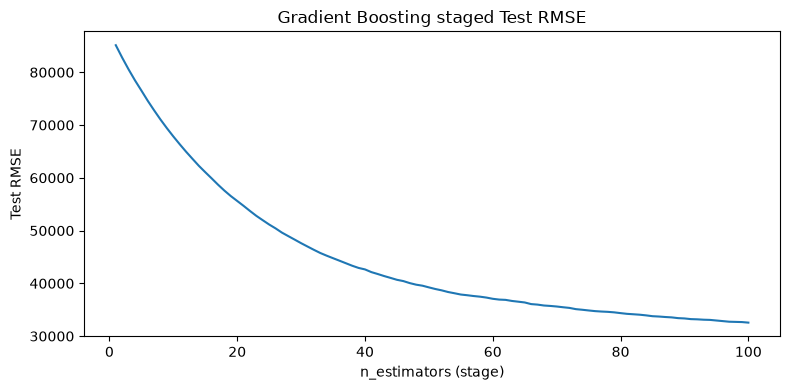

In [7]:
# TODO
# GradientBoostingRegressor를 학습하고
# staged_predict()를 이용해 단계별 Test RMSE를 확인하세요.
gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    random_state=42,
)
gbr.fit(X_train, y_train)

rmses = []
for pred in gbr.staged_predict(X_test):
    rmse = mean_squared_error(y_test, pred) ** 0.5
    rmses.append(rmse)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(rmses) + 1), rmses)
plt.xlabel("n_estimators (stage)")
plt.ylabel("Test RMSE")
plt.title("Gradient Boosting staged Test RMSE")
plt.tight_layout()
plt.show()


### Q2. 부스팅에서 나무를 순차적으로 추가하는 이유는 무엇인가요?

**답변:**  
이전 단계가 설명하지 못한 오차를 다음 나무가 보완하여 편향을 단계적으로 줄이기 위함입니다.


---

# 필수 2. XGBoost와 LightGBM 비교

## 문제 1. 두 모델을 같은 조건에서 학습하세요.

### 요구사항

다음 공통 설정을 사용합니다.

- `n_estimators=200`
- `learning_rate=0.05`
- `max_depth=3`
- `random_state=42`

다음 두 모델을 학습합니다.

- `XGBRegressor`
- `LGBMRegressor`

각 모델에 대해 다음을 확인합니다.

1. 학습 시간
2. Test RMSE

### 확인 포인트

- XGBoost와 LightGBM을 같은 데이터와 같은 주요 하이퍼파라미터 조건에서 비교했는가?
- LightGBM이 빠른 학습을 강점으로 갖는다는 교안 내용과 연결할 수 있는가?

In [8]:
# TODO
# XGBoost와 LightGBM의 학습 시간과 Test RMSE를 비교하세요.
common = dict(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)

xgb = XGBRegressor(**common)
start = time.time()
xgb.fit(X_train, y_train)
xgb_time = time.time() - start
xgb_rmse = mean_squared_error(y_test, xgb.predict(X_test)) ** 0.5

lgb = LGBMRegressor(**common)
start = time.time()
lgb.fit(X_train, y_train)
lgb_time = time.time() - start
lgb_rmse = mean_squared_error(y_test, lgb.predict(X_test)) ** 0.5

compare = pd.DataFrame([
    {"model": "XGBoost", "fit_seconds": xgb_time, "test_rmse": xgb_rmse},
    {"model": "LightGBM", "fit_seconds": lgb_time, "test_rmse": lgb_rmse},
])
display(compare)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000266 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1378
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 12
[LightGBM] [Info] Start training from score 181441.541952
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

,model,fit_seconds,test_rmse
0,XGBoost,0.054587,28399.711548
1,LightGBM,0.036035,31813.091613


### Q3. XGBoost와 LightGBM의 기본 트리 성장 방식 차이는 무엇인가요?

**답변:**  
XGBoost는 수준별(level-wise) 성장이 기본이고, LightGBM은 리프 중심(leaf-wise) 성장이 기본입니다.


### Q4. CatBoost의 구조적 특징과 강점은 무엇인가요?

**답변:**  
범주형 특성을 잘 다루도록 설계되었고, ordered boosting 등으로 타깃 누수를 줄이며 범주형 전처리 부담이 적은 것이 강점입니다.


## 문제 2. learning_rate와 n_estimators의 관계를 확인하세요.

### 요구사항

다음 조합을 비교합니다.

```python
settings = [
    {"learning_rate": 0.1, "n_estimators": 50},
    {"learning_rate": 0.05, "n_estimators": 100},
    {"learning_rate": 0.01, "n_estimators": 300}
]
```

각 조합에 대해 `GradientBoostingRegressor(max_depth=2, random_state=42)`를 학습하고 다음을 확인합니다.

1. Test RMSE
2. 학습 시간

### 확인 포인트

- learning_rate가 작을수록 더 많은 나무가 필요할 수 있음을 확인했는가?
- 성능뿐 아니라 학습 시간도 함께 확인했는가?

In [9]:
# TODO
# learning_rate / n_estimators 조합별 Test RMSE와 학습 시간을 비교하세요.
settings = [
    {"learning_rate": 0.1, "n_estimators": 50},
    {"learning_rate": 0.05, "n_estimators": 100},
    {"learning_rate": 0.01, "n_estimators": 300},
]

rows = []
for s in settings:
    model = GradientBoostingRegressor(max_depth=2, random_state=42, **s)
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t0
    rmse = mean_squared_error(y_test, model.predict(X_test)) ** 0.5
    rows.append({**s, "fit_seconds": elapsed, "test_rmse": rmse})

display(pd.DataFrame(rows))


,learning_rate,n_estimators,fit_seconds,test_rmse
0,0.10,50,0.048618,31791.283180
1,0.05,100,0.088877,32559.186347
2,0.01,300,0.274524,37165.991330


### Q5. learning_rate를 작게 만들면 왜 n_estimators를 함께 늘려야 할 수 있나요?

**답변:**  
각 단계 기여가 작아지므로 같은 성능을 내려면 더 많은 나무를 쌓아야 할 수 있기 때문입니다.


---

# 과제 1. Early Stopping과 부스팅 모델 선택

## 배경

교안에서는 `n_estimators`를 충분히 크게 설정하고, 검증 성능이 더 이상 좋아지지 않으면 학습을 멈추는 **Early Stopping**을 소개했습니다.

이번 과제에서는 XGBoost에서 이 흐름을 적용합니다.

> 과제는 필수 실습에서 사용한 모델과 하이퍼파라미터를 그대로 활용하는 수준입니다.

## 요구사항

1. Train 데이터를 다시 Train / Validation으로 나눕니다.
2. `XGBRegressor`를 사용합니다.
3. `n_estimators=1000`
4. `learning_rate=0.05`
5. `max_depth=3`
6. `early_stopping_rounds=20`
7. Train 데이터로 학습하고 Validation 데이터를 `eval_set`으로 전달합니다.
8. Test 데이터의 RMSE를 계산합니다.
9. 실제로 사용된 나무 수를 확인합니다.
10. `n_estimators=1000`을 모두 사용하지 않고 중간에 멈췄다면 그 이유를 설명합니다.

11. Q7에서 배깅·랜덤포레스트·부스팅의 작동 원리와 편향·분산, 과적합에 미치는 영향을 비교합니다. 새로운 모델 학습 코드는 요구하지 않습니다.

### 확인 포인트

- Early Stopping이 Validation 성능을 기준으로 동작한다는 점을 이해했는가?
- 불필요하게 많은 나무를 쌓는 것을 막는 목적을 설명할 수 있는가?
- 과적합 방지와 학습 시간 절약이라는 두 가지 의미를 설명할 수 있는가?
- 배깅의 부트스트랩·예측 결합, 랜덤포레스트의 특성 무작위 선택, 부스팅의 순차적 오류 보완을 설명할 수 있는가?
- 각 방식이 편향·분산에 미치는 일반적인 영향과 과적합 가능성을 구분할 수 있는가?


In [10]:
# TODO
# XGBoost에 Early Stopping을 적용하세요.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

xgb_es = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
)

try:
    xgb_es.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        early_stopping_rounds=20,
        verbose=False,
    )
except TypeError:
    # newer xgboost: early_stopping_rounds in constructor / callbacks
    xgb_es = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
        early_stopping_rounds=20,
    )
    xgb_es.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

test_rmse = mean_squared_error(y_test, xgb_es.predict(X_test)) ** 0.5
best_it = getattr(xgb_es, "best_iteration", None)
print("Test RMSE:", test_rmse)
print("best_iteration:", best_it)
if best_it is not None:
    print("사용된 나무 수:", best_it + 1)
else:
    print("사용된 나무 수:", xgb_es.n_estimators)


Test RMSE: 28840.572532458504
best_iteration: 141
사용된 나무 수: 142


### Q6. Early Stopping은 어떤 상황에서 학습을 멈추나요?

**답변:**  
검증 성능이 일정 rounds 동안 더 이상 개선되지 않을 때 학습을 멈춥니다.


### Q7. 배깅·랜덤포레스트·부스팅의 작동 원리와 편향·분산에 미치는 영향을 비교하세요.

**답변:**

- 배깅: 부트스트랩 표본으로 여러 모델을 병렬 학습하고 예측을 평균/투표로 결합해 주로 분산을 줄입니다.
- 랜덤포레스트: 배깅에 더해 분할 후보 특성을 무작위로 골라 트리 간 상관을 낮추고 분산을 추가로 줄입니다.
- 부스팅: 이전 오차를 순차 보완해 주로 편향을 줄입니다. 과도하면 과적합 위험이 있어 learning_rate·early stopping 등으로 조절합니다.


---

# 실습 마무리

아래 질문에 짧게 답해보세요.

1. 부스팅은 여러 모델을 병렬로 학습하나요, 순차적으로 학습하나요?
2. AdaBoost는 이전 모델이 틀린 샘플을 어떻게 처리하나요?
3. Gradient Boosting은 다음 모델이 무엇을 학습하나요?
4. XGBoost와 LightGBM의 기본 트리 성장 방식은 어떻게 다른가요?
5. `learning_rate`와 `n_estimators`는 어떤 관계가 있나요?
6. Early Stopping을 사용하는 이유는 무엇인가요?
7. 부스팅은 편향과 분산 중 어떤 문제를 줄이는 데 특히 초점을 두나요?